In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Sklearn — preprocessing ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ── Sklearn — models ────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Sklearn — evaluation ────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = {'no': '#4C72B0', 'yes': '#DD8452'}

print('✅  All libraries imported successfully.')

✅  All libraries imported successfully.


In [5]:
# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_excel('Bank_Marketing_Dataset.xlsx')

print(f'Shape  : {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()
df.head()

Shape  : 45,211 rows  ×  17 columns
Memory : 27.00 MB



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
#handling missing values
missing = df.isnull().sum()
print('=== Missing Values ===')
print(missing[missing > 0] if missing.any() else 'No missing values found ✅')
print()
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Missing Values ===
No missing values found ✅

Duplicate rows: 0


In [8]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', '50%'])

,count,mean,std,min,25%,50%,75%,max
age,45211.000000,40.936210,10.618762,18.000000,33.000000,39.000000,48.000000,95.000000
balance,45211.000000,1362.272058,3044.765829,-8019.000000,72.000000,448.000000,1428.000000,102127.000000
day,45211.000000,15.806419,8.322476,1.000000,8.000000,16.000000,21.000000,31.000000
duration,45211.000000,258.163080,257.527812,0.000000,103.000000,180.000000,319.000000,4918.000000
campaign,45211.000000,2.763841,3.098021,1.000000,1.000000,2.000000,3.000000,63.000000
pdays,45211.000000,40.197828,100.128746,-1.000000,-1.000000,-1.000000,-1.000000,871.000000
previous,45211.000000,0.580323,2.303441,0.000000,0.000000,0.000000,0.000000,275.000000


Target Distribution (y):
  no   39,922  (88.3%)  ████████████████████████████████████████████
  yes   5,289  (11.7%)  █████


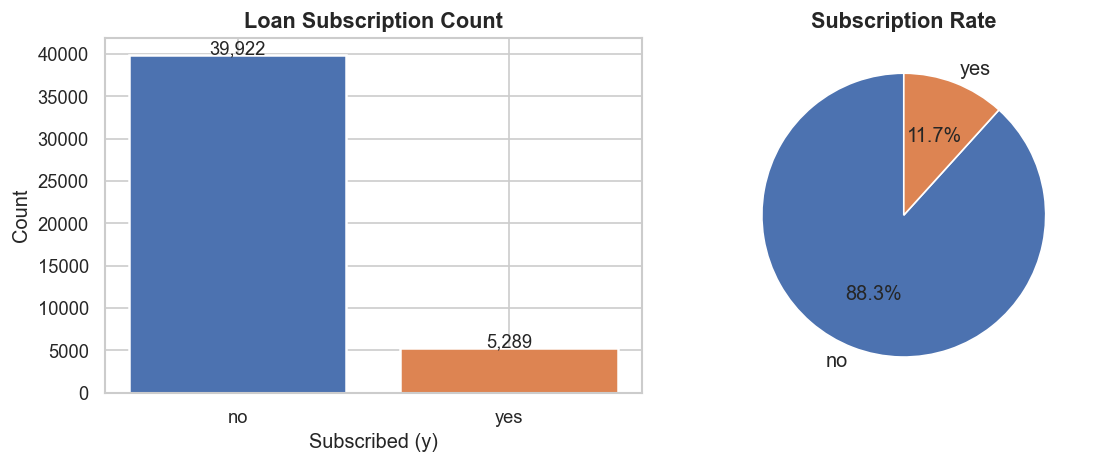

In [10]:
#Target variable Distribution
target_counts = df['y'].value_counts()
target_pct    = df['y'].value_counts(normalize=True) * 100

print('Target Distribution (y):') 
for label, count, pct in zip(target_counts.index, target_counts, target_pct):
    bar = '█' * int(pct / 2)
    print(f'  {label:3s}  {count:6,}  ({pct:.1f}%)  {bar}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(target_counts.index, target_counts.values,
            color=[PALETTE[k] for k in target_counts.index], edgecolor='white', linewidth=1.5)
axes[0].set_title('Loan Subscription Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            colors=[PALETTE[k] for k in target_counts.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Subscription Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', bbox_inches='tight')
plt.show()

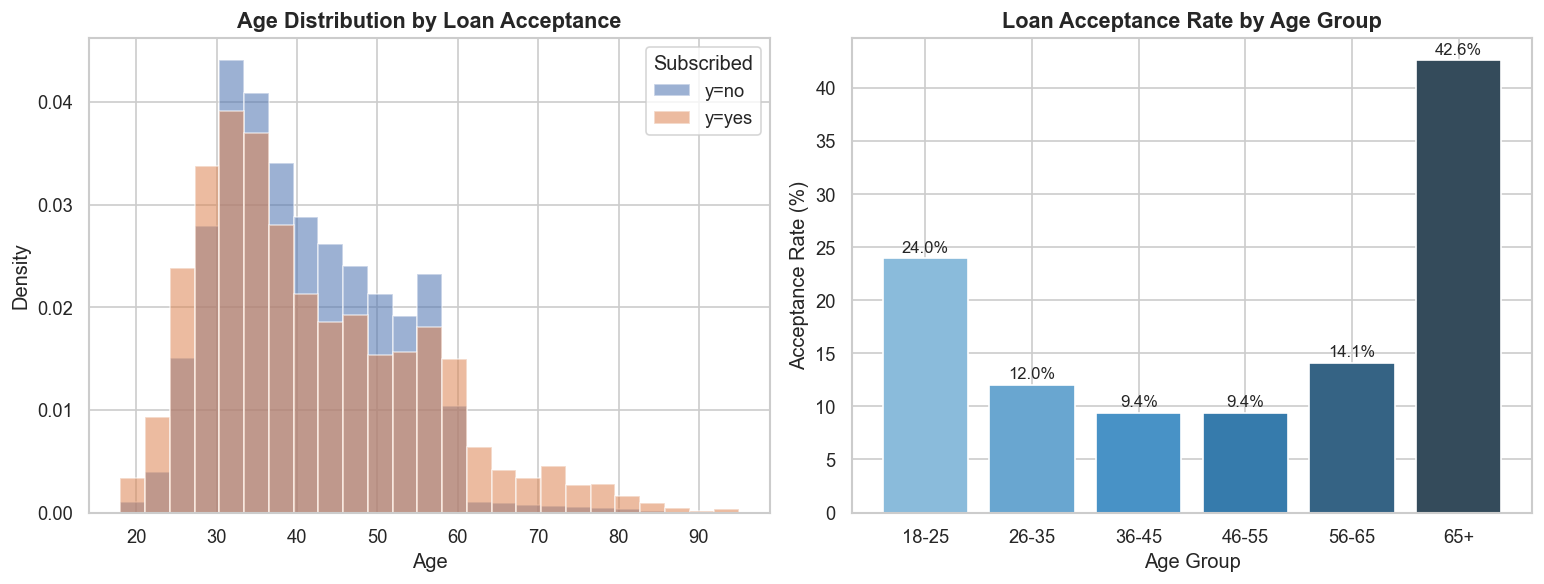

In [11]:
#Age Distribution by Loan Acceptance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KDE plot
for label, grp in df.groupby('y'):
    axes[0].hist(grp['age'], bins=25, alpha=0.55, label=f'y={label}',
                 color=PALETTE[label], edgecolor='white', density=True)
axes[0].set_title('Age Distribution by Loan Acceptance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].legend(title='Subscribed')

# Age group acceptance rate
df['age_group'] = pd.cut(df['age'], bins=[17, 25, 35, 45, 55, 65, 100],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])
age_rate = df.groupby('age_group', observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100).reset_index()
age_rate.columns = ['age_group', 'acceptance_rate']

bars = axes[1].bar(age_rate['age_group'].astype(str), age_rate['acceptance_rate'],
                    color=sns.color_palette('Blues_d', len(age_rate)), edgecolor='white')
axes[1].set_title('Loan Acceptance Rate by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Acceptance Rate (%)')
for bar, val in zip(bars, age_rate['acceptance_rate']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                  f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('02_age_analysis.png', bbox_inches='tight')
plt.show()

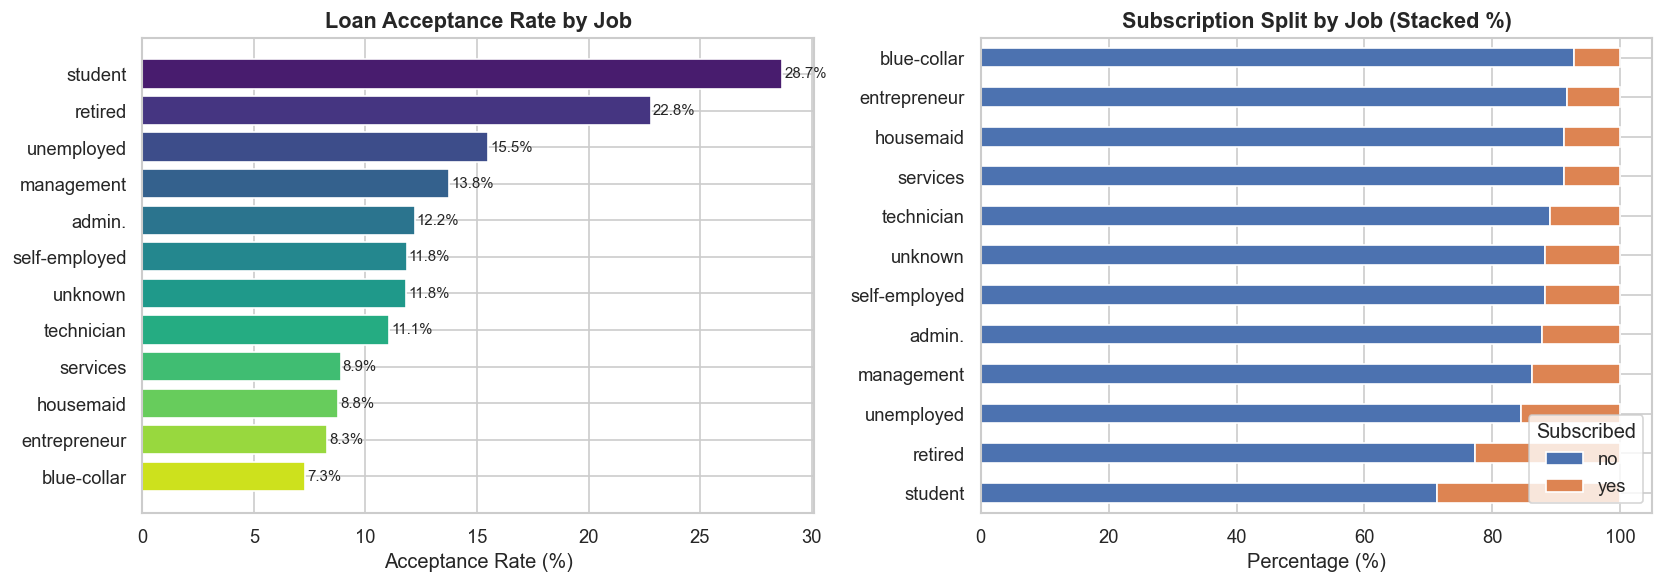

In [12]:
#job type vs loan acceptance
job_rate = (df.groupby('job')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .sort_values(ascending=False)
              .reset_index())
job_rate.columns = ['job', 'acceptance_rate']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acceptance rate by job
colors = sns.color_palette('viridis', len(job_rate))
axes[0].barh(job_rate['job'], job_rate['acceptance_rate'], color=colors, edgecolor='white')
axes[0].set_title('Loan Acceptance Rate by Job', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Acceptance Rate (%)')
for i, v in enumerate(job_rate['acceptance_rate']):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].invert_yaxis()

# Stacked bar — yes/no count per job
job_counts = df.groupby(['job', 'y'], observed=True).size().unstack(fill_value=0)
job_counts_pct = job_counts.div(job_counts.sum(axis=1), axis=0) * 100
job_counts_pct = job_counts_pct.loc[job_rate['job']]  # same order
job_counts_pct.plot(kind='barh', stacked=True, ax=axes[1],
                     color=[PALETTE['no'], PALETTE['yes']], edgecolor='white')
axes[1].set_title('Subscription Split by Job (Stacked %)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Percentage (%)')
axes[1].set_ylabel('')
axes[1].legend(title='Subscribed', loc='lower right')

plt.tight_layout()
plt.savefig('03_job_analysis.png', bbox_inches='tight')
plt.show()

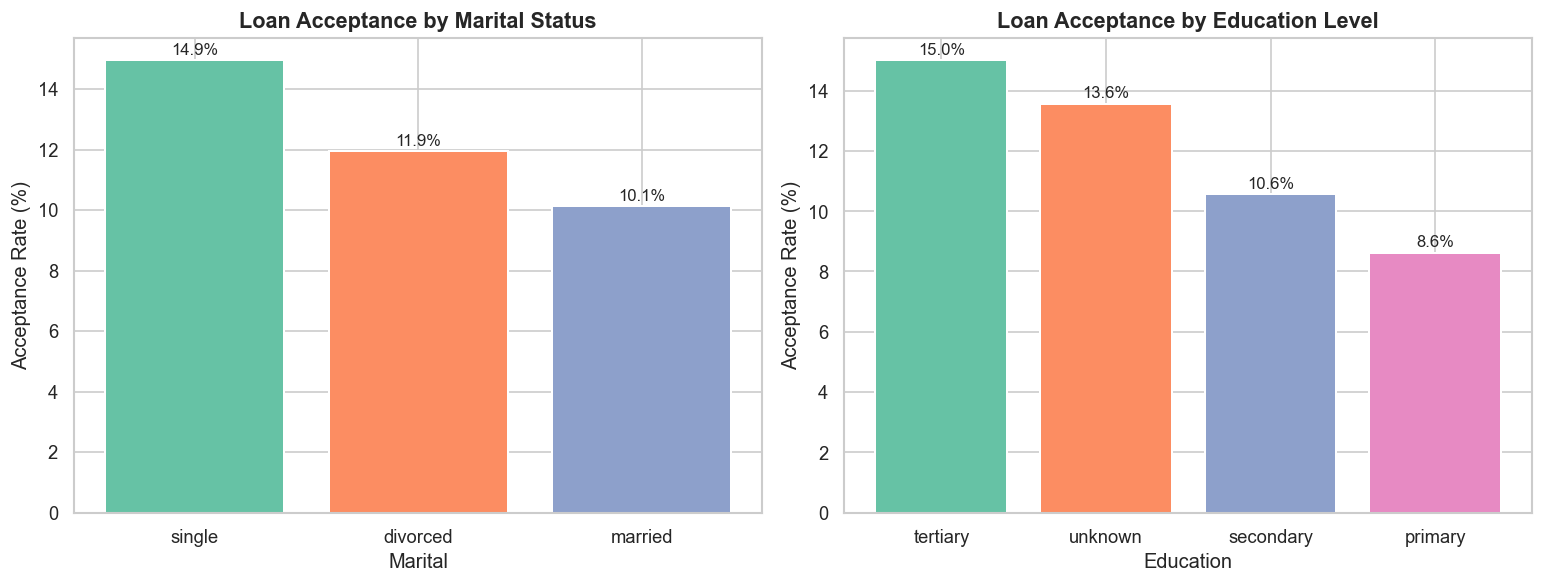

In [13]:
#marital status and education vs loan acceptance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(
    axes,
    ['marital', 'education'],
    ['Loan Acceptance by Marital Status', 'Loan Acceptance by Education Level']
):
    rate = (df.groupby(col)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .sort_values(ascending=False)
              .reset_index())
    rate.columns = [col, 'acceptance_rate']

    bars = ax.bar(rate[col], rate['acceptance_rate'],
                   color=sns.color_palette('Set2', len(rate)), edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Acceptance Rate (%)')
    for bar, val in zip(bars, rate['acceptance_rate']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('04_marital_education.png', bbox_inches='tight')
plt.show()

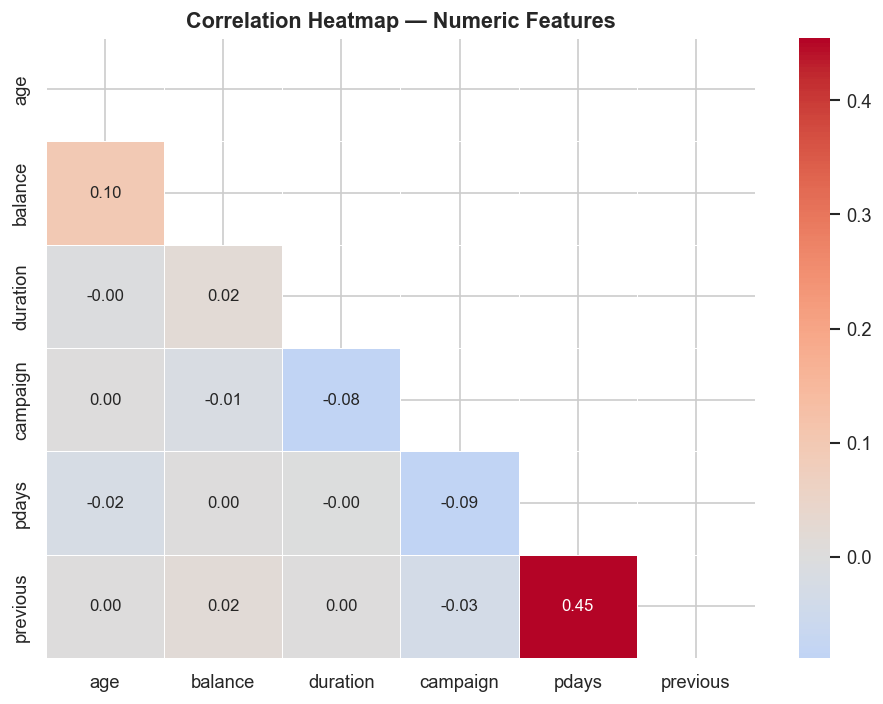

In [15]:
#correlation heatmap
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [16]:
#feature engineering and encoding
# ── Working copy ─────────────────────────────────────────────────────────────
data = df.drop(columns=['age_group'], errors='ignore').copy()

# ── Encode binary yes/no columns ─────────────────────────────────────────────
binary_cols = ['default', 'housing', 'loan', 'y']
for col in binary_cols:
    data[col] = (data[col] == 'yes').astype(int)

# ── One-hot encode remaining categoricals ────────────────────────────────────
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print(f'Features after encoding: {data.shape[1]} columns')
print(f'Target balance: {data["y"].value_counts().to_dict()}')
data.head(3)

Features after encoding: 43 columns
Target balance: {0: 39922, 1: 5289}


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,261,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
1,44,0,29,1,0,5,151,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
2,33,0,2,1,1,5,76,1,-1,0,...,False,False,False,True,False,False,False,False,False,True


In [17]:
#Train / Test  Split
X = data.drop(columns=['y'])
y = data['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'Class split (train): {dict(y_train.value_counts().sort_index())}')


Training set : 36,168 rows
Test set     : 9,043 rows
Class split (train): {0: np.int64(31937), 1: np.int64(4231)}


In [18]:
#Train Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_pipeline.fit(X_train, y_train)
lr_pred  = lr_pipeline.predict(X_test)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]

lr_acc   = accuracy_score(y_test, lr_pred)
lr_f1    = f1_score(y_test, lr_pred)
lr_auc   = roc_auc_score(y_test, lr_proba)

print('=== Logistic Regression Performance ===')
print(f'Accuracy  : {lr_acc:.4f}')
print(f'F1 Score  : {lr_f1:.4f}')
print(f'ROC-AUC   : {lr_auc:.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=['No Loan', 'Loan']))

=== Logistic Regression Performance ===
Accuracy  : 0.8460
F1 Score  : 0.5528
ROC-AUC   : 0.9079

              precision    recall  f1-score   support

     No Loan       0.97      0.85      0.91      7985
        Loan       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



In [19]:
#Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    max_depth=6, min_samples_split=20, min_samples_leaf=10,
    class_weight='balanced', random_state=42
)

dt_model.fit(X_train, y_train)
dt_pred  = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

dt_acc  = accuracy_score(y_test, dt_pred)
dt_f1   = f1_score(y_test, dt_pred)
dt_auc  = roc_auc_score(y_test, dt_proba)

print('=== Decision Tree Performance ===')
print(f'Accuracy  : {dt_acc:.4f}')
print(f'F1 Score  : {dt_f1:.4f}')
print(f'ROC-AUC   : {dt_auc:.4f}')
print()
print(classification_report(y_test, dt_pred, target_names=['No Loan', 'Loan']))

=== Decision Tree Performance ===
Accuracy  : 0.7956
F1 Score  : 0.4951
ROC-AUC   : 0.8883

              precision    recall  f1-score   support

     No Loan       0.98      0.79      0.87      7985
        Loan       0.35      0.86      0.50      1058

    accuracy                           0.80      9043
   macro avg       0.66      0.82      0.68      9043
weighted avg       0.90      0.80      0.83      9043



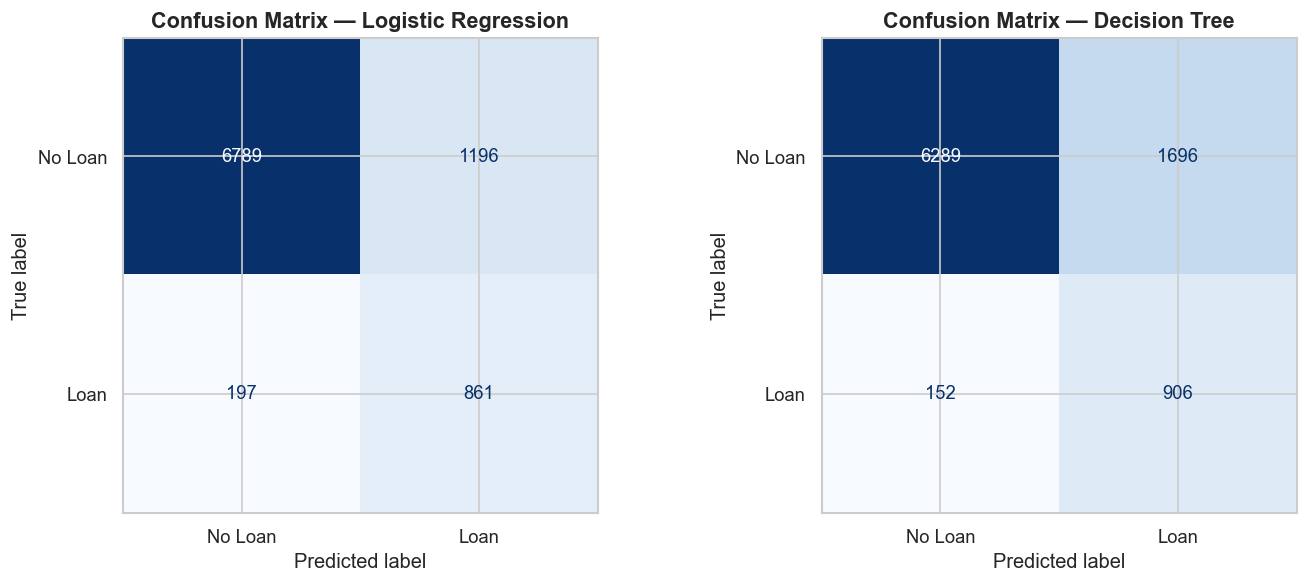

In [20]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [lr_pred, dt_pred],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Loan', 'Loan'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('07_confusion_matrices.png', bbox_inches='tight')
plt.show()

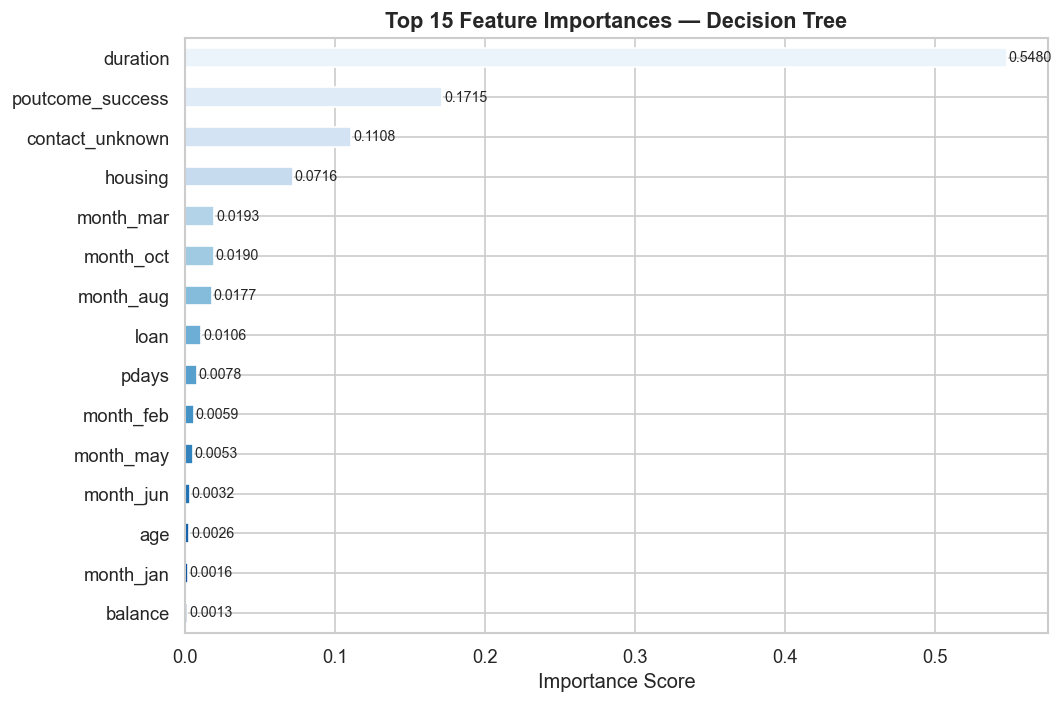

In [21]:
#feature importance decision tree
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('Blues_r', len(top15))
top15.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 15 Feature Importances — Decision Tree', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(top15.sort_values()):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('10_feature_importance.png', bbox_inches='tight')
plt.show()

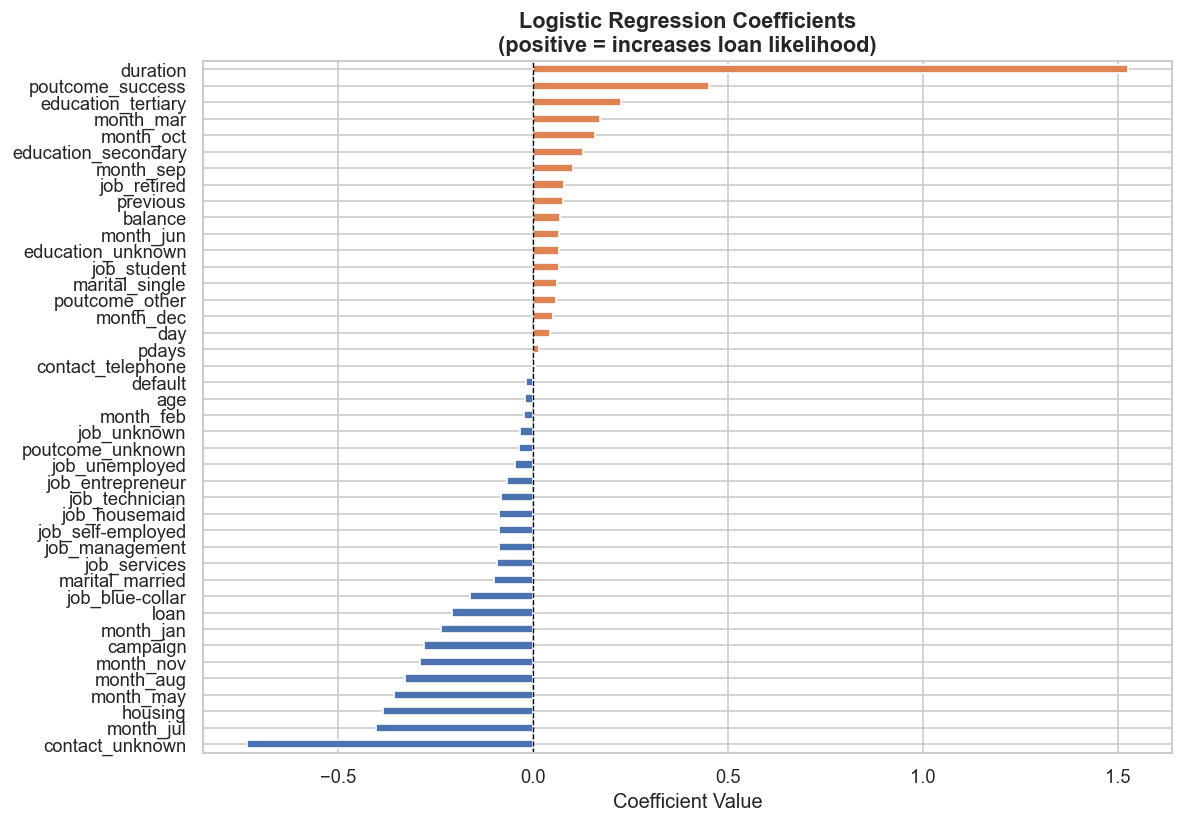

In [22]:
#logistic regression coefficients
coef = pd.Series(
    lr_pipeline.named_steps['model'].coef_[0],
    index=X.columns
).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in coef]
coef.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression Coefficients\n(positive = increases loan likelihood)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('11_lr_coefficients.png', bbox_inches='tight')
plt.show()

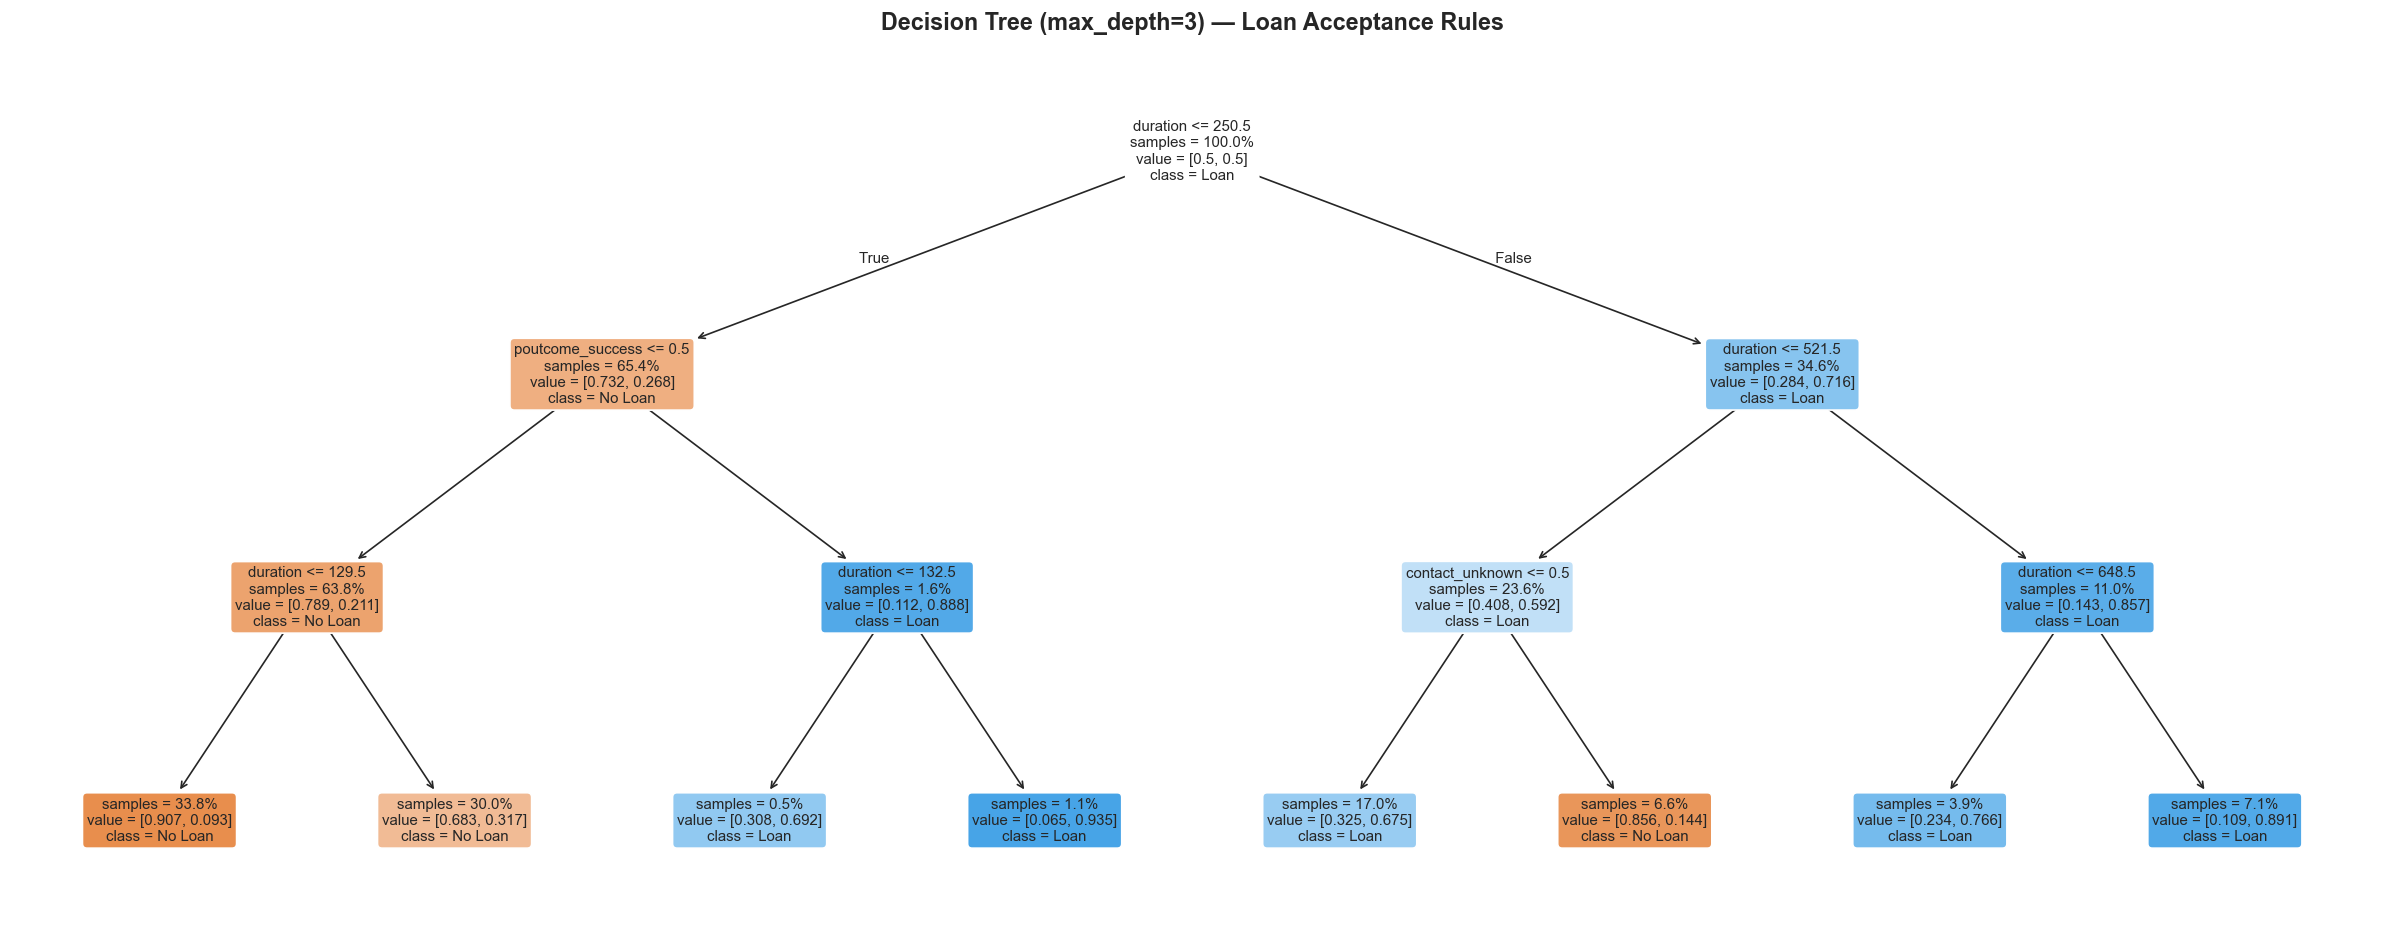

In [23]:
#decision treee visualization
# Shallow tree for interpretability
dt_vis = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dt_vis.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_vis, feature_names=X.columns.tolist(),
    class_names=['No Loan', 'Loan'],
    filled=True, rounded=True, fontsize=9, ax=ax,
    impurity=False, proportion=True
)
ax.set_title('Decision Tree (max_depth=3) — Loan Acceptance Rules',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('12_decision_tree_viz.png', bbox_inches='tight', dpi=150)
plt.show()

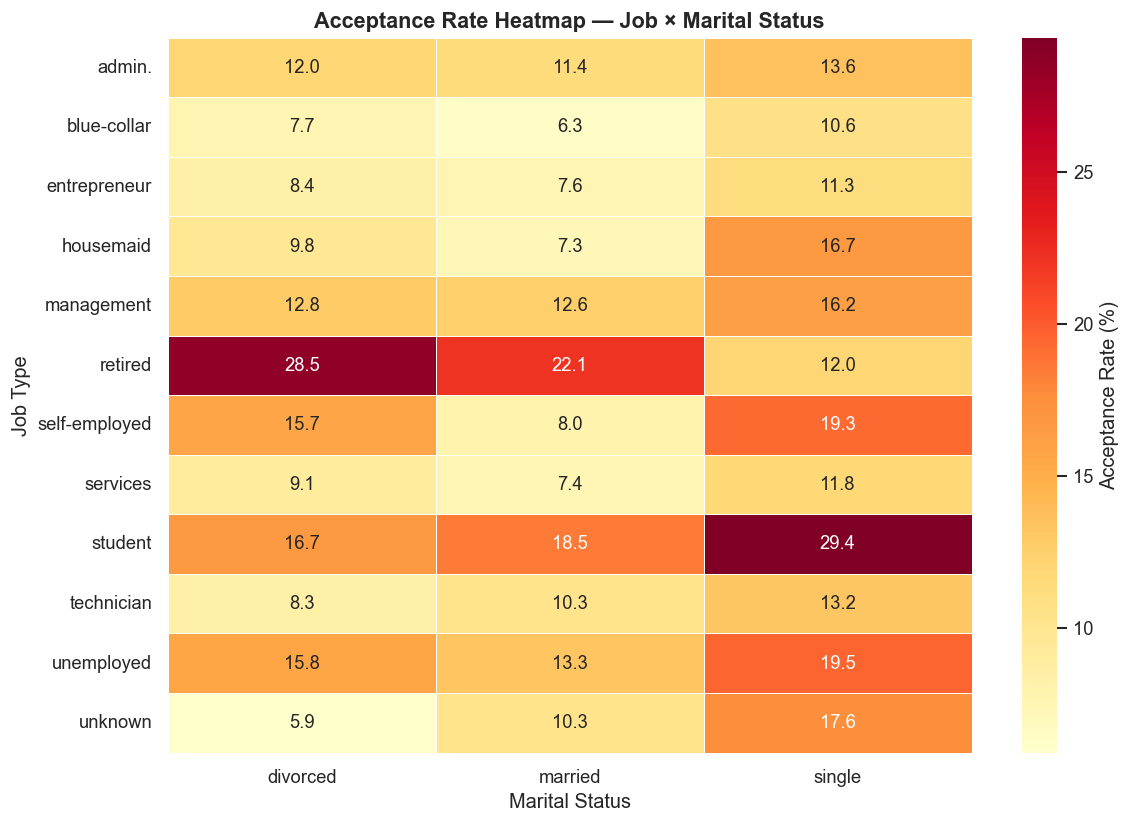


📌 Top 5 Most Receptive Customer Segments:
          Job  Marital  Acceptance_Rate_%
      student   single               29.4
      retired divorced               28.5
      retired  married               22.1
   unemployed   single               19.5
self-employed   single               19.3
      student  married               18.5
      unknown   single               17.6
    housemaid   single               16.7
      student divorced               16.7
   management   single               16.2


In [25]:
#customer segment analysis
# Use original (pre-encoded) df for readability
df_orig = df.copy()

# Segment: job × marital
seg = (df_orig.groupby(['job', 'marital'])['y']
              .apply(lambda x: round((x == 'yes').mean() * 100, 1))
              .reset_index())
seg.columns = ['Job', 'Marital', 'Acceptance_Rate_%']

pivot = seg.pivot(index='Job', columns='Marital', values='Acceptance_Rate_%').fillna(0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Acceptance Rate (%)'})
ax.set_title('Acceptance Rate Heatmap — Job × Marital Status',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Marital Status')
ax.set_ylabel('Job Type')

plt.tight_layout()
plt.savefig('13_segment_heatmap.png', bbox_inches='tight')
plt.show()

# Top 5 most receptive segments
print('\n📌 Top 5 Most Receptive Customer Segments:')
print(seg.sort_values('Acceptance_Rate_%', ascending=False).head(10).to_string(index=False))

In [26]:
#high probability customer segmentation
# Attach prediction probabilities back to original test rows
test_idx   = y_test.index
df_results = df.iloc[test_idx].copy()
df_results['predicted_probability'] = lr_proba
df_results['predicted_label']       = np.where(lr_pred == 1, 'Yes', 'No')
df_results['actual_label']          = np.where(y_test.values == 1, 'Yes', 'No')

high_prob = df_results[df_results['predicted_probability'] >= 0.70]
print(f'High-probability customers (≥70% score): {len(high_prob):,}')
print(f'\nJob distribution of high-probability customers:')
print(high_prob['job'].value_counts().to_string())

print(f'\nAge stats of high-probability customers:')
print(high_prob['age'].describe().round(1))

High-probability customers (≥70% score): 1,346

Job distribution of high-probability customers:
job
management       337
technician       212
blue-collar      167
admin.           158
retired          146
services          86
student           73
unemployed        60
self-employed     47
entrepreneur      26
housemaid         25
unknown            9

Age stats of high-probability customers:
count    1346.0
mean       41.7
std        13.5
min        18.0
25%        32.0
50%        38.0
75%        50.0
max        93.0
Name: age, dtype: float64
